# New Section

In [ ]:
pip install pandas numpy matplotlib seaborn plotly

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
import os

# List contents of the directory to verify the file name
print(os.listdir('/content/sample_data/'))

['anscombe.json', 'README.md', 'mnist_test.csv', 'california_housing_train.csv', 'mnist_train_small.csv', 'california_housing_test.csv']


In [ ]:
df = pd.read_csv('/content/Authorizations From new.csv')

In [ ]:
df.head()

,Fiscal Year,Decision Date,Effective Date,Expiration Date,Unique Identifier,Deal Number,Decision,Brokered,Deal Cancelled,Country,...,Primary Source of Repayment (PSOR),Working Capital Delegated Authority,Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount,Small Business Authorized Amount,Woman Owned Authorized Amount,Minority Owned Authorized Amount,Loan Interest Rate
0,2007,11/29/2006,-,12/15/2011,08003048XA0002,AP003048AA,Approved,No,No,Private Export Funding Corp.,...,Various Us Companies,NaN,24500000.0,24500000.0,0.0,0.0,0,0,0,-
1,2007,11/29/2006,11/29/2006,12/15/2016,08003048XA0003,AP003048AA,Approved,No,No,Private Export Funding Corp.,...,Various Us Companies,NaN,50000000.0,50000000.0,0.0,0.0,0,0,0,-
2,2007,8/16/2007,8/16/2007,9/15/2017,08003048XA0004,AP003048AA,Approved,No,No,Private Export Funding Corp.,...,Various Us Companies,NaN,136250000.0,136250000.0,0.0,0.0,0,0,0,-
3,2007,9/21/2007,9/21/2007,7/31/2008,08064737XM0001,AP064737XM,Approved,No,No,United States,...,American General Supplies,Yes,2700000.0,2700000.0,0.0,0.0,2700000,0,2700000,-
4,2007,11/24/2006,11/24/2006,1/1/2007,08069888XG0003,AP069888XG,Approved,No,No,United States,...,Kell-Strom Tool Co Inc,Yes,233307.9,233307.9,0.0,0.0,0,0,0,-


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52122 entries, 0 to 52121
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Fiscal Year                            52122 non-null  int64  
 1   Decision Date                          52122 non-null  object 
 2   Effective Date                         52122 non-null  object 
 3   Expiration Date                        51435 non-null  object 
 4   Unique Identifier                      52122 non-null  object 
 5   Deal Number                            52122 non-null  object 
 6   Decision                               52122 non-null  object 
 7   Brokered                               52122 non-null  object 
 8   Deal Cancelled                         52122 non-null  object 
 9   Country                                52122 non-null  object 
 10  Program                                52122 non-null  object 
 11  Po

In [ ]:
df.isnull().sum()

,0
Fiscal Year,0
Decision Date,0
Effective Date,0
Expiration Date,687
Unique Identifier,0
Deal Number,0
Decision,0
Brokered,0
Deal Cancelled,0
Country,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.describe()

,Fiscal Year,Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount
count,52122.000000,5.212200e+04,5.212200e+04,5.212200e+04,5.212200e+04
mean,2014.653735,5.062607e+06,4.278951e+06,2.971763e+05,3.381671e+05
std,4.963450,4.304212e+07,3.243071e+07,1.371985e+07,1.225878e+07
min,2007.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2011.000000,2.000000e+05,0.000000e+00,0.000000e+00,0.000000e+00
50%,2014.000000,5.000000e+05,3.000000e+05,0.000000e+00,0.000000e+00
75%,2018.000000,1.076896e+06,1.510634e+06,0.000000e+00,0.000000e+00
max,2025.000000,3.595031e+09,2.942954e+09,2.046587e+09,2.344489e+09


In [ ]:
df.columns

Index(['Fiscal Year', 'Decision Date', 'Effective Date', 'Expiration Date',
       'Unique Identifier', 'Deal Number', 'Decision', 'Brokered',
       'Deal Cancelled', 'Country', 'Program', 'Policy Type',
       'Decision Authority', 'Primary Export Product NAICS/SIC code',
       'Product Description', 'Term', 'Primary Applicant', 'Primary Lender',
       'Primary Exporter', 'Primary Exporter City',
       'Primary Exporter State Code', 'Primary Exporter State Name',
       'Primary Borrower', 'Primary Source of Repayment (PSOR)',
       'Working Capital Delegated Authority', 'Approved/Declined Amount',
       'Disbursed/Shipped Amount', 'Undisbursed Exposure Amount',
       'Outstanding Exposure Amount', 'Small Business Authorized Amount',
       'Woman Owned Authorized Amount', 'Minority Owned Authorized Amount',
       'Loan Interest Rate'],
      dtype='object')

In [ ]:
df['Approved/Declined Amount'] = (
    df['Approved/Declined Amount']
    .replace(r'[$,]', '', regex=True)
    .astype(float)
)

In [ ]:
df['Decision Date'] = pd.to_datetime(df['Decision Date'])

In [ ]:
df['Year'] = df['Decision Date'].dt.year

In [ ]:
dftotal_financing = df['Approved/Declined Amount'].sum()

print("Total Financing:", dftotal_financing)

Total Financing: 263873195671.36002


In [ ]:
top_countries = df.groupby('Country')['Approved/Declined Amount'].sum().sort_values(ascending=False).head(10)

print(top_countries)

Country
Multiple - Countries    6.291138e+10
United States           3.469683e+10
Mexico                  1.757530e+10
India                   1.039876e+10
Turkey                  9.674265e+09
United Arab Emirates    9.038631e+09
Saudi Arabia            7.878409e+09
China                   6.892988e+09
Ireland                 6.348528e+09
Korea, South            6.329782e+09
Name: Approved/Declined Amount, dtype: float64


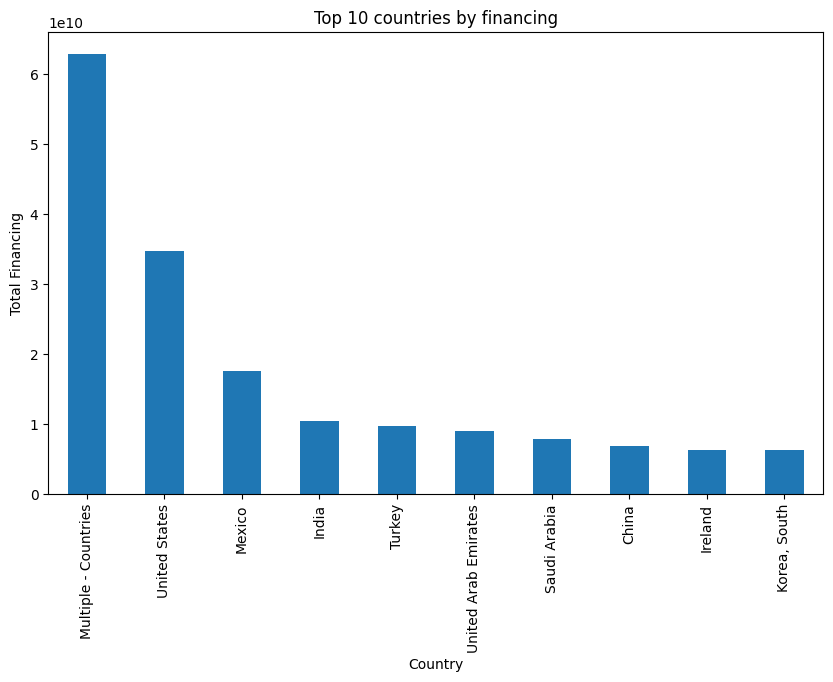

In [ ]:
top_countries.plot(kind='bar',figsize=(10,6))
plt.xlabel('Country')
plt.ylabel('Total Financing')
plt.title('Top 10 countries by financing')
plt.show()

In [ ]:
top_industries = df.groupby('Primary Export Product NAICS/SIC code')['Approved/Declined Amount'].sum().sort_values(ascending=False).head(10)

print(top_industries)

Primary Export Product NAICS/SIC code
336411    5.337635e+10
-         4.655522e+10
3721A     1.738033e+10
8711      9.655088e+09
3721      9.629453e+09
332410    5.029334e+09
211112    5.005293e+09
3511      4.453263e+09
3663      3.612050e+09
9999      3.047349e+09
Name: Approved/Declined Amount, dtype: float64


In [ ]:
df['Exposure Ratio'] = df['Outstanding Exposure Amount'] / df['Approved/Declined Amount']

In [ ]:
high_risk = df.sort_values(by='Exposure Ratio', ascending=False)
high_risk.head()

,Fiscal Year,Decision Date,Effective Date,Expiration Date,Unique Identifier,Deal Number,Decision,Brokered,Deal Cancelled,Country,...,Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount,Small Business Authorized Amount,Woman Owned Authorized Amount,Minority Owned Authorized Amount,Loan Interest Rate,Year,Exposure Ratio
49350,2024,2023-12-07,12/15/2023,3/31/2025,08089513XXAF01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,1.525158e+08,0.0,1.691966e+08,0,0,0,-,2023,inf
49349,2024,2023-12-07,12/15/2023,12/31/2024,08089513XXAD01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,4.651046e+07,0.0,4.578371e+07,0,0,0,-,2023,inf
49348,2024,2023-12-07,12/15/2023,1/31/2024,08089513XXAC01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,4.657179e+07,0.0,4.520345e+07,0,0,0,-,2023,inf
49347,2024,2023-12-07,12/15/2023,1/31/2024,08089513XXAB01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,1.481925e+08,0.0,1.404594e+08,0,0,0,-,2023,inf
49346,2024,2023-12-07,12/15/2023,1/31/2024,08089513XXAA01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,4.251693e+07,0.0,4.048878e+07,0,0,0,-,2023,inf


In [ ]:
high_risk = df.sort_values(by='Exposure Ratio', ascending=False)

high_risk.head()

,Fiscal Year,Decision Date,Effective Date,Expiration Date,Unique Identifier,Deal Number,Decision,Brokered,Deal Cancelled,Country,...,Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount,Small Business Authorized Amount,Woman Owned Authorized Amount,Minority Owned Authorized Amount,Loan Interest Rate,Year,Exposure Ratio
49350,2024,2023-12-07,12/15/2023,3/31/2025,08089513XXAF01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,1.525158e+08,0.0,1.691966e+08,0,0,0,-,2023,inf
49349,2024,2023-12-07,12/15/2023,12/31/2024,08089513XXAD01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,4.651046e+07,0.0,4.578371e+07,0,0,0,-,2023,inf
49348,2024,2023-12-07,12/15/2023,1/31/2024,08089513XXAC01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,4.657179e+07,0.0,4.520345e+07,0,0,0,-,2023,inf
49347,2024,2023-12-07,12/15/2023,1/31/2024,08089513XXAB01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,1.481925e+08,0.0,1.404594e+08,0,0,0,-,2023,inf
49346,2024,2023-12-07,12/15/2023,1/31/2024,08089513XXAA01,AP089513XX,Approved,No,No,Ethiopia,...,0.0,4.251693e+07,0.0,4.048878e+07,0,0,0,-,2023,inf


In [ ]:
small_business = df.groupby('Small Business Authorized Amount')['Approved/Declined Amount'].sum()

print(small_business)

Small Business Authorized Amount
0                1.290499e+11
1.001.502.832    1.396841e+06
1.003.023.567    1.619474e+06
1.003.739.614    1.399077e+06
1.006.241.863    2.165358e+06
                     ...     
99909.9          9.990990e+04
9991517          9.991517e+06
99990            4.950000e+05
999999           1.499998e+07
999999.9         3.000000e+06
Name: Approved/Declined Amount, Length: 4102, dtype: float64


In [ ]:
women_owned = df.groupby('Woman Owned Authorized Amount')['Approved/Declined Amount'].sum()
print(women_owned)

Woman Owned Authorized Amount
0                2.505320e+11
1.063.601.272    1.181779e+07
1.159.471.452    9.418939e+05
1.163.773.275    6.982500e+06
1.357.259.788    2.068994e+08
                     ...     
980000           1.960000e+06
9900             9.900000e+03
99000            9.900000e+04
990000           6.930000e+06
993750           9.937500e+05
Name: Approved/Declined Amount, Length: 409, dtype: float64


In [ ]:
minority = df.groupby('Minority Owned Authorized Amount')['Approved/Declined Amount'].sum()
print(minority)

Minority Owned Authorized Amount
0                2.424970e+11
1.106.493.675    1.315688e+06
1.126.843.196    5.496796e+08
1.159.471.452    9.418939e+05
1.163.773.275    6.982500e+06
                     ...     
97500            1.950000e+05
9900             1.980000e+04
99000            9.900000e+04
990000           9.900000e+05
9960200.9        9.960201e+06
Name: Approved/Declined Amount, Length: 443, dtype: float64


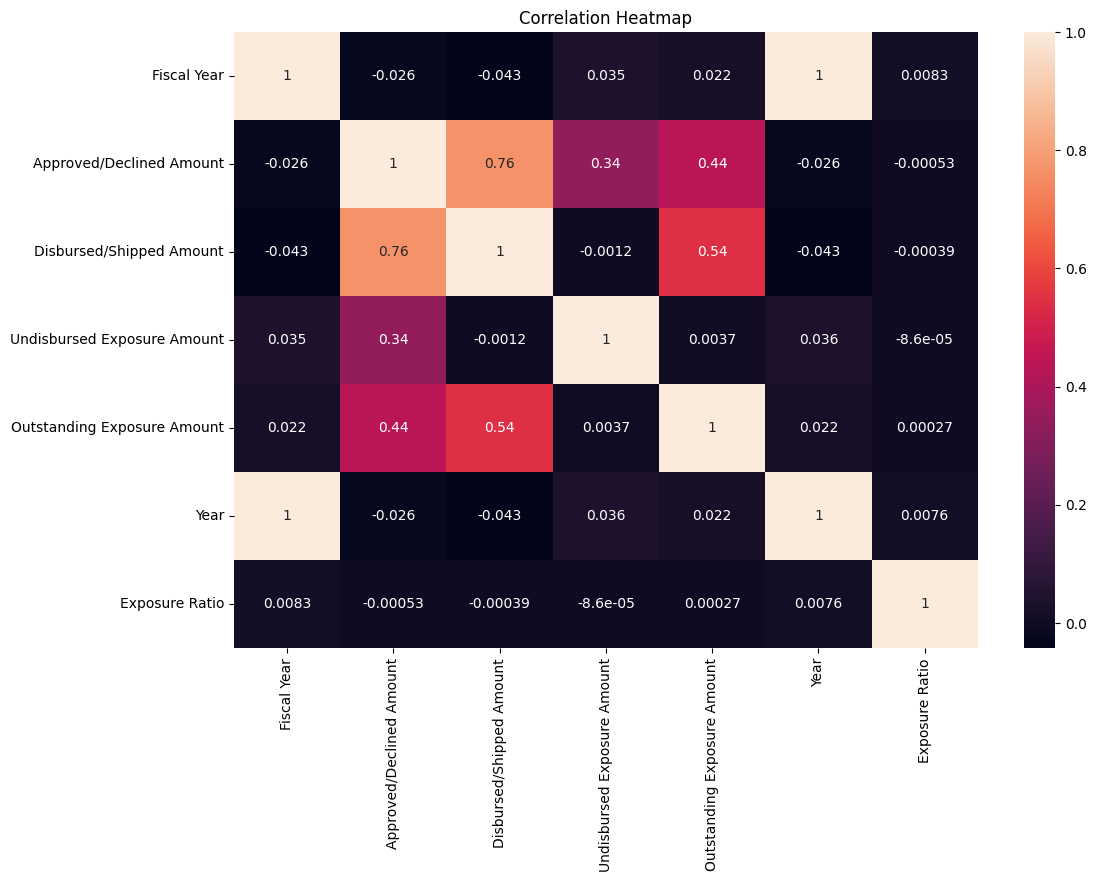

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df.to_csv('cleaned_bank_data.csv', index=False)